# SCAN Compositional Interference (CI) demo

One representative checkpoint from the ACS paper's Section 3 SCAN sweep: `d_model=12`, `8%` training coverage, `seed=42` (10-layer toy decoder-only Transformer, `n_heads=4`, `d_ff=48`, best layer 6).

`d_model=12` is used here (rather than the smallest `d_model=8` checkpoint) because CI's signal is visibly cleaner once the model isn't capacity-starved: at `d_model=8` the model is only 47% accurate and the curves are noisy; at `d_model=12` it's 96% accurate and the cumulative/noncumulative curves are smooth and near-monotonic, and the error-recall curve clears the diagonal by ~8x more (AUC-above-diagonal 0.224 vs. 0.029).

This notebook, in order:
1. the pairwise-CI lower-triangle heatmap and 2D PCA of this checkpoint's atomic-concept representations,
2. the cumulative, noncumulative, and error-recall curves — computed with the same numeric routines as `he_probe/analysis_atomic_avg.py`, styled to match `Representational-Homomorphism-.../PAPER_PLOTS_scan.ipynb`'s `_plot_setup`/`_plot_setup_noncum`/heatmap/PCA cells (serif figure style, thick curves, in-axis PR-AUC/R tables) rather than that script's own plain default-matplotlib plots,
3. the 10 SCAN test examples with the highest CI, ranked high to low, with the gold action sequence and whether the model actually got each one right.

It needs no GPU and does not reload the trained model — everything runs off the checkpoint's already-computed per-example table (`demo_data/size_p8_dmodel12/layer6_test_scores.csv`), its heatmap/PCA data (`heatmap_pca_data.json`), and its saved atomic-concept representations (`..._atomic_reps_avg_train.pt`), all copied in from
`results_scan_paper_new_dev/size_p8/` in `Representational-Homomorphism-for-Transformer-Language-Models` (see `ACS/README.md`, Section III, for attribution).

**Run this notebook from `ACS/SCAN/`** so the `he_probe` package resolves.

In [1]:
import csv
import json
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from IPython.display import Image, display

# Make sure `he_probe` resolves as a package regardless of exactly where
# Jupyter's cwd ended up, as long as it's this notebook's own directory or below it.
NOTEBOOK_DIR = Path.cwd()
for _cand in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (_cand / "he_probe").is_dir():
        NOTEBOOK_DIR = _cand
        break
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

# Numeric curve computations only (binning / correlation) — reused as-is from the
# analysis pipeline, not reimplemented. The plotting/style layer below instead
# follows Representational-Homomorphism-.../PAPER_PLOTS_scan.ipynb's _plot_setup /
# _plot_setup_noncum / lower-triangle-heatmap / PCA cells, adapted for a single
# checkpoint instead of that notebook's multi-checkpoint overlay.
from he_probe.analysis_atomic_avg import (
    cumulative_mean_accuracy,
    noncumulative_fixedwidth_accuracy,
    pearson_r_p,
)

# Same paper-figure style as PAPER_PLOTS_scan.ipynb's heatmap/PCA/curve cells.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
})

CATEGORY_COLORS = {
    "primitive": "#1A1AFF",
    "modifier":  "#008200",
    "repeater":  "#FFAA00",
    "connector": "#FF0000",
}
BLUE = plt.cm.Blues(0.75)
ORANGE = plt.cm.Oranges(0.75)


def show_fig(fig):
    """Render a matplotlib figure inline as PNG — robust regardless of backend
    (unlike plt.show(), which silently renders nothing under a non-interactive
    backend), and unlike raw SVG display, PNG renders in every notebook viewer
    including GitHub's."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))


def _fmt_p(p):
    if not np.isfinite(p):
        return "NA"
    return "<0.01" if p < 0.01 else f"{p:.2f}"


def _set_sparse_ticks(ax, *, n_xticks=3, n_yticks=3, x_as_percent=True):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    xticks = np.linspace(xmin, xmax, n_xticks)
    yticks = np.linspace(ymin, ymax, n_yticks)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    if x_as_percent:
        ax.set_xticklabels([f"{int(round(t * 100))}%" for t in xticks])
    else:
        ax.set_xticklabels([f"{t:.2f}" for t in xticks])
    ax.set_yticklabels([f"{t:.2f}" for t in yticks])


def _pr_auc_legend_table(ax, legend_items, *, x0=0.36, y0=0.06, row_gap=0.075,
                          col1_x=0.00, col2_x=0.34, fontsize=15, header_fontsize=15):
    """In-axis 'PR-AUC / Baseline' table — same layout as PAPER_PLOTS_scan.ipynb."""
    n = len(legend_items)
    ax.text(x0 + col1_x, y0 + row_gap * n, "PR-AUC", transform=ax.transAxes,
            fontsize=header_fontsize, fontweight="bold", ha="left", va="bottom")
    ax.text(x0 + col2_x, y0 + row_gap * n, "Baseline", transform=ax.transAxes,
            fontsize=header_fontsize, fontweight="bold", ha="left", va="bottom")
    for r, item in enumerate(legend_items):
        y = y0 + row_gap * (n - 1 - r)
        ax.text(x0 + col1_x, y, item.get("pr_auc_failure", ""), transform=ax.transAxes,
                fontsize=fontsize, fontweight="bold", color=item["blue"], ha="left", va="bottom")
        ax.text(x0 + col2_x, y, item.get("failure_rate", ""), transform=ax.transAxes,
                fontsize=fontsize, fontweight="bold", color=item["orange"], ha="left", va="bottom")


def _corr_legend_table(ax, legend_items, *, x0=0.46, y0=0.06, row_gap=0.085,
                        col1_x=0.00, col2_x=0.26, fontsize=15, header_fontsize=15):
    """In-axis 'R / p' table — same layout as PAPER_PLOTS_scan.ipynb."""
    n = len(legend_items)
    ax.text(x0 + col1_x, y0 + row_gap * n, "R", transform=ax.transAxes,
            fontsize=header_fontsize, fontweight="bold", ha="left", va="bottom")
    ax.text(x0 + col2_x, y0 + row_gap * n, "p", transform=ax.transAxes,
            fontsize=header_fontsize, fontweight="bold", ha="left", va="bottom")
    for r, item in enumerate(legend_items):
        y = y0 + row_gap * (n - 1 - r)
        ax.text(x0 + col1_x, y, item["r"], transform=ax.transAxes,
                fontsize=fontsize, fontweight="bold", color=item["blue"], ha="left", va="bottom")
        ax.text(x0 + col2_x, y, item["p"], transform=ax.transAxes,
                fontsize=fontsize, fontweight="bold", color=item["blue"], ha="left", va="bottom")

In [2]:
DEMO_DIR = NOTEBOOK_DIR / "demo_data" / "size_p8_dmodel12"
CSV_PATH = DEMO_DIR / "layer6_test_scores.csv"
METRICS_PATH = DEMO_DIR / "best_layer_metrics.json"
HEATMAP_PCA_PATH = DEMO_DIR / "heatmap_pca_data.json"

with open(METRICS_PATH) as f:
    best_layer_metrics = json.load(f)
with open(HEATMAP_PCA_PATH) as f:
    heatmap_pca_data = json.load(f)

BEST_LAYER = best_layer_metrics["best_layer"]
D_MODEL = best_layer_metrics["d_model"]
COVERAGE = best_layer_metrics["size_variation_p"]
BIN_WIDTH = 0.1  # matches --bin_width for this run (see demo_data/.../analysis_config.json)
avg_acc = best_layer_metrics["avg_acc"]


def load_rows(csv_path):
    """Load per-example rows and attach CI = 1 - orthogonality.

    orthogonality here is the `cumulative_coherence` aggregation's `1 - CI` score
    (see example_orthogonality_score in analysis_atomic_avg.py): low orthogonality
    = concepts in the example are coherent = high interference = hard example.
    """
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            r["index"] = int(r["index"])
            r["n_primitives"] = int(r["n_primitives"])
            r["n_pairs"] = int(r["n_pairs"])
            r["correct"] = int(r["correct"])
            r["orthogonality"] = float(r["orthogonality"])
            r["CI"] = 1.0 - r["orthogonality"]
            rows.append(r)
    return rows


rows = load_rows(CSV_PATH)
rows_sorted = sorted(rows, key=lambda r: r["orthogonality"])

print(
    f"Loaded {len(rows)} SCAN test examples "
    f"(seed {best_layer_metrics['seed']}, d_model={D_MODEL}, "
    f"coverage={COVERAGE}%, best layer={BEST_LAYER})."
)

Loaded 17310 SCAN test examples (seed 42, d_model=12, coverage=8%, best layer=6).


## 1. Pairwise CI heatmap

Lower-triangle heatmap of CI between every pair of atomic concept tokens present in this checkpoint's best layer, colored red (near-orthogonal, low CI, easy to compose) to blue (coherent, high CI, high interference — the diagonal is always CI=1, a token vs. itself). Tick labels are colored by token category (primitive / modifier / repeater / connector).

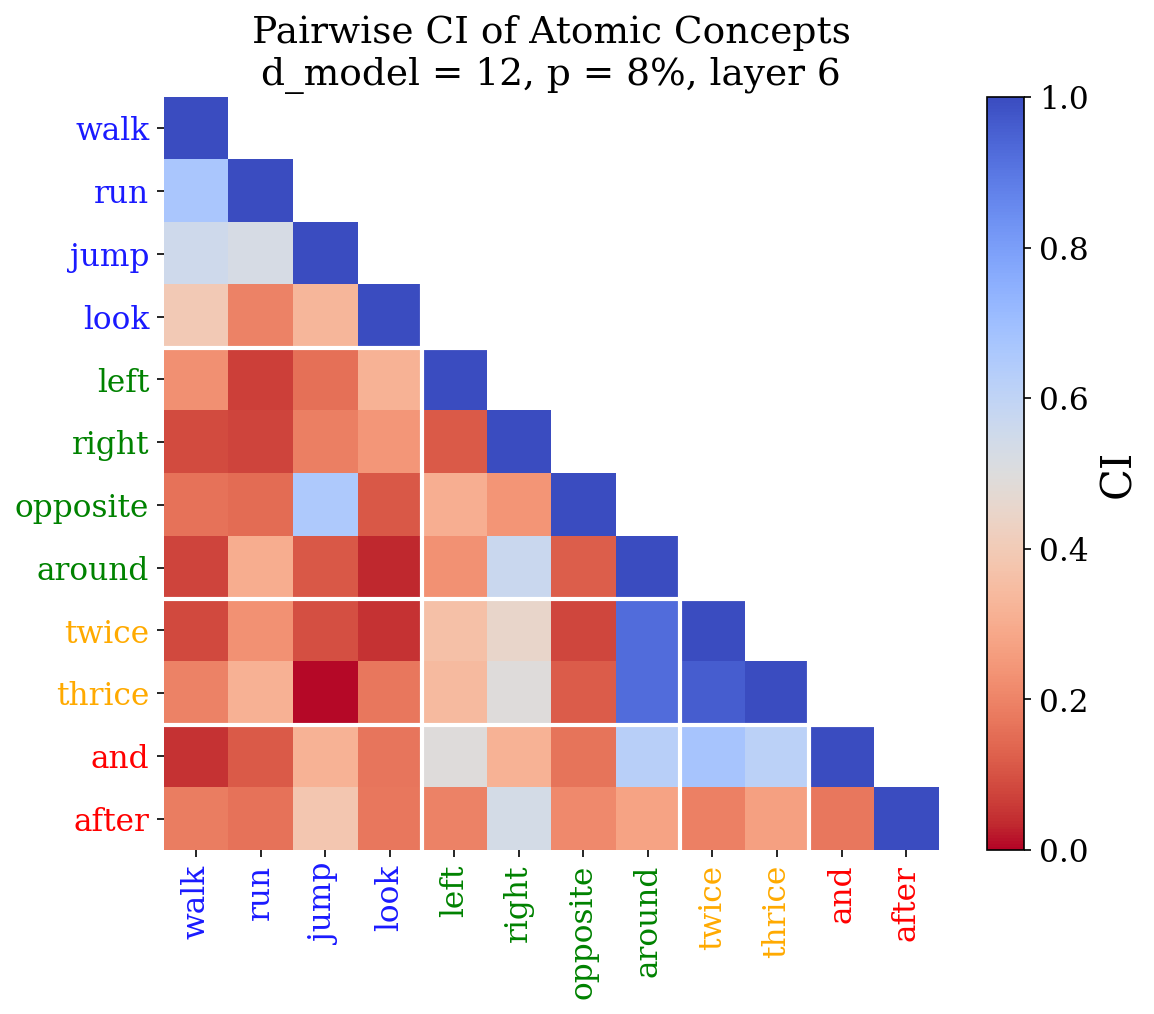

In [3]:
hm = heatmap_pca_data["heatmap"]
tokens = hm["tokens"]
categories = hm["categories"]
# Stored values are 1 - CI (same convention as the "orthogonality" CSV column); invert for CI.
matrix = 1.0 - np.array(hm["matrix"])
n_tok = len(tokens)

merged_categories = [
    "modifier" if cat in {"direction", "manner"} else cat
    for cat in categories
]

# keep LOWER triangle including diagonal
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
matrix_masked = np.ma.array(matrix, mask=mask)

cmap = plt.get_cmap("coolwarm_r").copy()
cmap.set_bad(color="white")
norm = TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)

fig, ax = plt.subplots(figsize=(max(8, n_tok * 0.45), max(7, n_tok * 0.4)))
im = ax.imshow(matrix_masked, cmap=cmap, norm=norm, aspect="auto")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("CI", fontsize=20)
cbar.ax.tick_params(labelsize=15)

ax.set_xticks(range(n_tok))
ax.set_yticks(range(n_tok))
ax.set_xticklabels(tokens, rotation=90, fontsize=15)
ax.set_yticklabels(tokens, fontsize=15)

for tick_label, cat in zip(ax.get_xticklabels(), merged_categories):
    tick_label.set_color(CATEGORY_COLORS.get(cat, "gray"))
for tick_label, cat in zip(ax.get_yticklabels(), merged_categories):
    tick_label.set_color(CATEGORY_COLORS.get(cat, "gray"))

for i in range(1, n_tok):
    if merged_categories[i] != merged_categories[i - 1]:
        ax.axhline(i - 0.5, color="white", linewidth=2.0)
        ax.axvline(i - 0.5, color="white", linewidth=2.0)

ax.set_title(
    "Pairwise CI of Atomic Concepts\n"
    f"d_model = {D_MODEL}, p = {COVERAGE}%, layer {BEST_LAYER}"
)
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
show_fig(fig)

## 2. Atomic concept representations (2D PCA)

The same atomic-concept vectors, projected to 2D and normalized to the unit circle. Rays close together (small angle) are the high-CI, hard-to-compose concept pairs; rays near-orthogonal to each other are easy to compose.

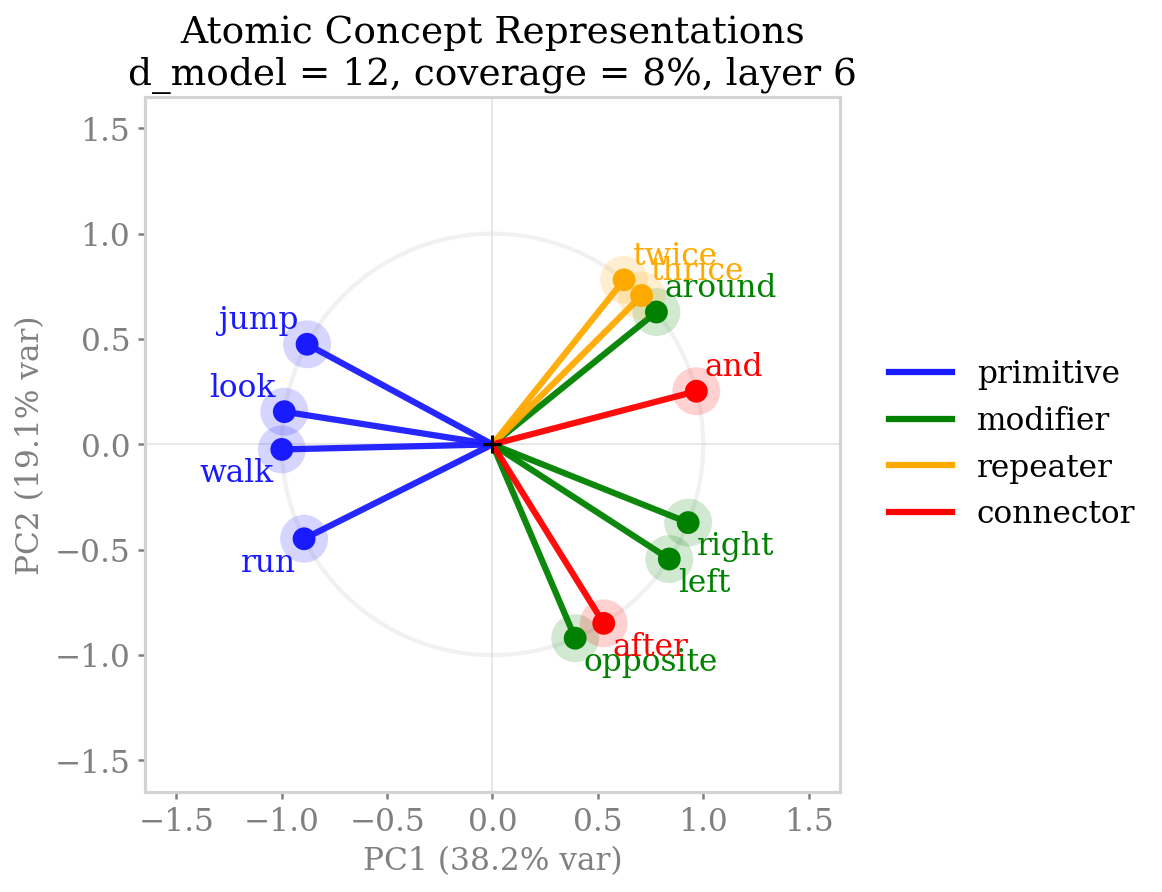

In [4]:
pca_data = heatmap_pca_data["pca_2d"]
tokens_pca = pca_data["tokens"]
categories_pca = pca_data["categories"]
vectors = np.array(pca_data["vectors"])

merged_categories_pca = [
    "modifier" if cat in {"direction", "manner"} else cat
    for cat in categories_pca
]

pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)
norms = np.linalg.norm(coords, axis=1, keepdims=True)
coords = coords / np.where(norms > 0, norms, 1)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 8))
seen_cats = set()

for i, (tok, cat) in enumerate(zip(tokens_pca, merged_categories_pca)):
    x, y = coords[i]
    color = CATEGORY_COLORS.get(cat, "gray")
    label = cat if cat not in seen_cats else "_nolegend_"
    seen_cats.add(cat)

    ax.annotate(
        "", xy=(x, y), xytext=(0, 0),
        arrowprops=dict(arrowstyle="-", color=color, lw=3.0, alpha=0.95),
        label=label, zorder=2,
    )
    ax.scatter(x, y, color=color, s=950 / 1.8, alpha=0.18, edgecolors="none", zorder=3)
    ax.scatter(x, y, color=color, s=180 / 1.5, edgecolors="none", zorder=4)

    off = 0.04
    ax.text(
        x + off * np.sign(x if x != 0 else 1),
        y + off * np.sign(y if y != 0 else 1),
        tok, fontsize=15, color=color,
        ha="left" if x >= 0 else "right",
        va="bottom" if y >= 0 else "top",
    )

ax.scatter(0, 0, color="black", s=80, zorder=5, marker="+")

legend_handles = [
    Line2D([0], [0], color=CATEGORY_COLORS[c], lw=3, label=c)
    for c in ["primitive", "modifier", "repeater", "connector"]
    if c in seen_cats
]
ax.legend(handles=legend_handles, fontsize=15, frameon=False, loc="center left", bbox_to_anchor=(1.03, 0.5))

circle = plt.Circle((0, 0), 1.0, fill=False, color="lightgray", lw=2, alpha=0.3)
ax.add_patch(circle)
ax.axhline(0, color="lightgray", lw=0.8, alpha=0.6, zorder=0)
ax.axvline(0, color="lightgray", lw=0.8, alpha=0.6, zorder=0)

ax.set_xlabel(f"PC1 ({var[0]:.1%} var)", fontsize=15, color="gray")
ax.set_ylabel(f"PC2 ({var[1]:.1%} var)", fontsize=15, color="gray")
ax.set_title(f"Atomic Concept Representations\nd_model = {D_MODEL}, coverage = {COVERAGE}%, layer {BEST_LAYER}")

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.65, 1.65)
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("lightgray")
    spine.set_linewidth(1.5)

ax.tick_params(axis="both", labelsize=15, colors="gray", width=1.2)
fig.tight_layout()
show_fig(fig)

## 3. Cumulative accuracy vs. CI

Sort test examples by CI (equivalently, by `orthogonality` ascending); at each percentile cutoff, plot the mean accuracy of the examples at or below it. If CI predicts failure, this curve should start low (high-CI examples are hard) and rise toward the overall average as low-CI examples are added. The in-plot table gives this checkpoint's precomputed CI-failure-prediction PR-AUC against the majority-baseline failure rate (both from `best_layer_metrics.json`, not recomputed here).

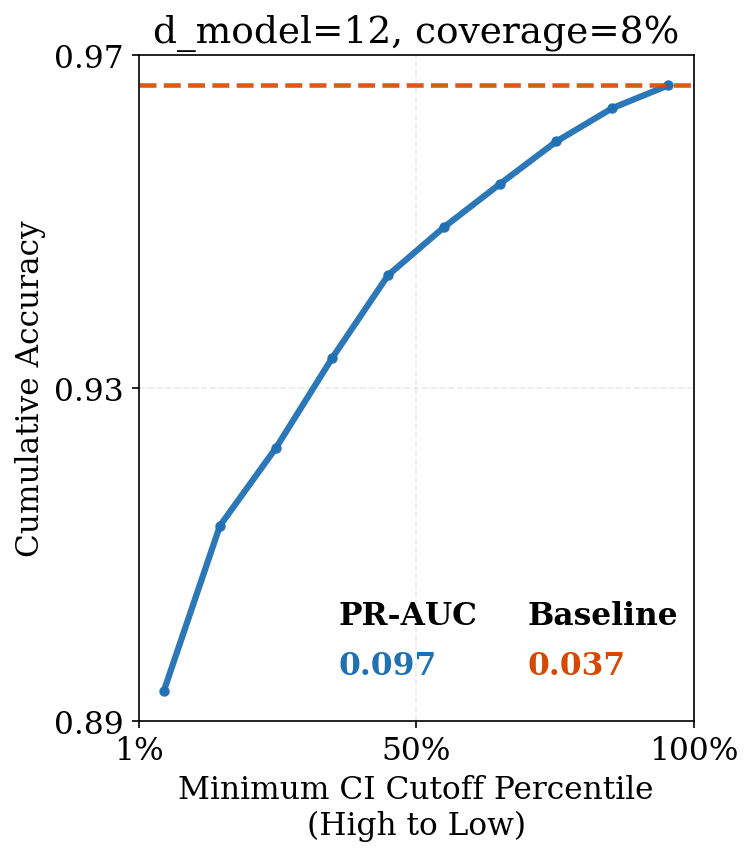

In [5]:
xs, ys = cumulative_mean_accuracy(rows_sorted, bin_width=BIN_WIDTH)

fig = plt.figure(figsize=(5, 6.0))
ax = fig.add_axes([0.13, 0.13, 0.74, 0.74])

ax.plot(xs, ys, color=BLUE, lw=3.0, alpha=0.95, marker="o", markersize=4)
ax.axhline(avg_acc, color=ORANGE, linestyle="--", lw=2.2, alpha=0.9)

ymin = float(min(np.min(ys), avg_acc))
ymax = float(max(np.max(ys), avg_acc))
pad = 0.05 * (ymax - ymin) if ymax > ymin else 0.02
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_xlabel("Minimum CI Cutoff Percentile\n(High to Low)")
ax.set_ylabel("Cumulative Accuracy")
ax.set_title(f"d_model={D_MODEL}, coverage={COVERAGE}%")
_set_sparse_ticks(ax, n_xticks=3, n_yticks=3, x_as_percent=True)
ax.grid(True, alpha=0.25, linestyle="--")

_pr_auc_legend_table(
    ax,
    [{
        "blue": BLUE, "orange": ORANGE,
        "pr_auc_failure": f"{best_layer_metrics['pr_auc_failure']:.3f}",
        "failure_rate": f"{best_layer_metrics['failure_rate']:.3f}",
    }],
)
show_fig(fig)

## 4. Noncumulative accuracy vs. CI

Same sort, but binned (not cumulative): mean accuracy within each CI percentile bin on its own, showing whether accuracy trends monotonically with CI rather than just in aggregate. The in-plot table gives the Pearson correlation between bin CI and bin accuracy.

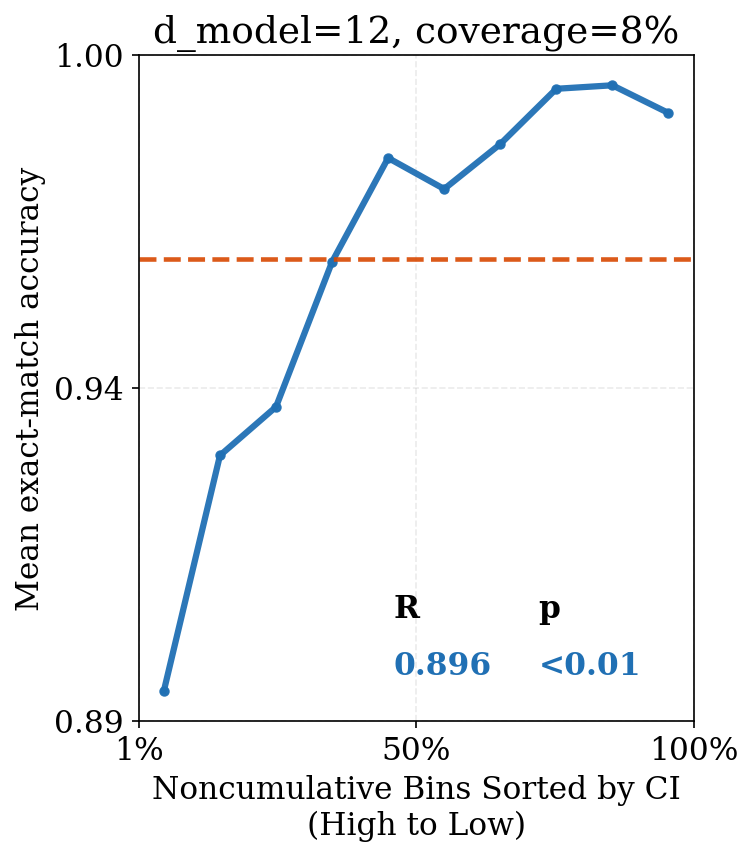

In [6]:
xs_n, ys_n, _counts = noncumulative_fixedwidth_accuracy(rows_sorted, bin_width=BIN_WIDTH)
r, p = pearson_r_p(xs_n, ys_n)

fig = plt.figure(figsize=(5, 6.0))
ax = fig.add_axes([0.13, 0.13, 0.74, 0.74])

ax.plot(xs_n, ys_n, color=BLUE, lw=3.0, alpha=0.95, marker="o", markersize=4)
ax.axhline(avg_acc, color=ORANGE, linestyle="--", lw=2.2, alpha=0.9)

ymin = float(min(np.min(ys_n), avg_acc))
ymax = float(max(np.max(ys_n), avg_acc))
pad = 0.05 * (ymax - ymin) if ymax > ymin else 0.02
ax.set_ylim(ymin - pad, ymax + pad)

ax.set_xlabel("Noncumulative Bins Sorted by CI\n(High to Low)")
ax.set_ylabel("Mean exact-match accuracy")
ax.set_title(f"d_model={D_MODEL}, coverage={COVERAGE}%")
_set_sparse_ticks(ax, n_xticks=3, n_yticks=3, x_as_percent=True)
ax.grid(True, alpha=0.25, linestyle="--")

_corr_legend_table(ax, [{"blue": BLUE, "r": f"{r:.3f}", "p": _fmt_p(p)}])
show_fig(fig)

## 5. Error-recall curve

Sort examples by CI descending (hardest-predicted first); X = fraction of the test set included, Y = fraction of all model errors captured. A curve above the diagonal means CI successfully front-loads the model's actual failures; the dotted line is a perfect predictor (all errors captured within the model's true failure rate).

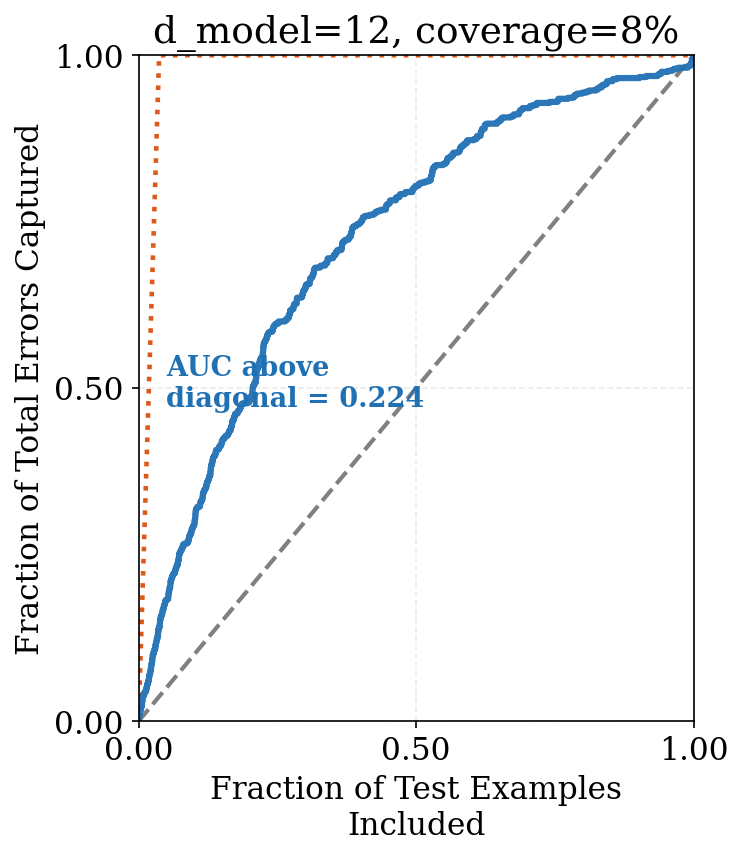

In [7]:
n = len(rows_sorted)
total_errors = sum(1 - r["correct"] for r in rows_sorted)
xs_e = np.arange(1, n + 1) / n
ys_e = np.cumsum([1 - r["correct"] for r in rows_sorted]) / total_errors
error_rate = total_errors / n
perfect_xs = np.array([0.0, error_rate, 1.0])
perfect_ys = np.array([0.0, 1.0, 1.0])
auc_above = float(np.trapezoid(ys_e - xs_e, xs_e))

fig = plt.figure(figsize=(5, 6.0))
ax = fig.add_axes([0.13, 0.13, 0.74, 0.74])

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=2.0)
ax.plot(perfect_xs, perfect_ys, linestyle=":", color=ORANGE, lw=2.2, alpha=0.9)
ax.plot(xs_e, ys_e, color=BLUE, lw=3.0, alpha=0.95)

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("Fraction of Test Examples\nIncluded")
ax.set_ylabel("Fraction of Total Errors Captured")
ax.set_title(f"d_model={D_MODEL}, coverage={COVERAGE}%")
_set_sparse_ticks(ax, n_xticks=3, n_yticks=3, x_as_percent=False)
ax.grid(True, alpha=0.25, linestyle="--")

ax.text(0.05, 0.55, f"AUC above\ndiagonal = {auc_above:.3f}", transform=ax.transAxes,
        fontsize=13, fontweight="bold", color=BLUE, ha="left", va="top")
show_fig(fig)

## 6. Top 10 most challenging SCAN examples — demo of CI's effectiveness

The 10 test examples with the **highest CI** (lowest `orthogonality`, i.e. the atomic concepts in the command are least separable in this checkpoint's representation space) — CI's prediction for "most likely to fail" — listed from high CI to low CI, with the SCAN command, the gold action sequence, and whether the model actually got it right.

In [8]:
rows_by_ci_desc = sorted(rows, key=lambda r: r["CI"], reverse=True)
top10 = rows_by_ci_desc[:10]

overall_acc = sum(r["correct"] for r in rows) / len(rows)
top10_acc = sum(r["correct"] for r in top10) / len(top10)

print(f"Overall accuracy (all {len(rows)} test examples):            {overall_acc:.3f}")
print(f"Accuracy among the 10 highest-CI (hardest-predicted) examples: {top10_acc:.3f}")
print()
print(f"{'rank':>4}  {'CI':>7}  {'result':^7}  {'n_prim':>6}  command  ->  gold answer")
print("-" * 110)
for i, r in enumerate(top10, start=1):
    mark = "correct" if r["correct"] else "WRONG"
    print(f"{i:>4}  {r['CI']:>7.4f}  {mark:^7}  {r['n_primitives']:>6}  {r['input']}  ->  {r['output']}")

Overall accuracy (all 17310 test examples):            0.963
Accuracy among the 10 highest-CI (hardest-predicted) examples: 0.700

rank       CI  result   n_prim  command  ->  gold answer
--------------------------------------------------------------------------------------------------------------
   1   0.7592  correct       5  turn around right twice and turn right thrice  ->  I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT
   2   0.7592  correct       5  turn right twice and turn around right thrice  ->  I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT
   3   0.7592   WRONG        5  turn around right thrice and turn right twice  ->  I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIG